## Imports

In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import scipy.ndimage.filters as filters
from materialy_feature_points import pm

## Load in images

In [36]:
folder_path = Path("./materialy_feature_points")
extensions = ["*.png", "*.jpg"]

image_paths = []
for ext in extensions:
    image_paths.extend(folder_path.glob(ext))

print(image_paths)

images = []
for path in image_paths:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    
    images.append(img)

[WindowsPath('materialy_feature_points/budynek1.jpg'), WindowsPath('materialy_feature_points/budynek2.jpg'), WindowsPath('materialy_feature_points/eiffel1.jpg'), WindowsPath('materialy_feature_points/eiffel2.jpg'), WindowsPath('materialy_feature_points/fontanna1.jpg'), WindowsPath('materialy_feature_points/fontanna2.jpg'), WindowsPath('materialy_feature_points/fontanna_pow.jpg'), WindowsPath('materialy_feature_points/left_panorama.jpg'), WindowsPath('materialy_feature_points/right_panorama.jpg')]


## Harris Method

In [37]:
fountain_1 = images[4]
fountain_2 = images[5]

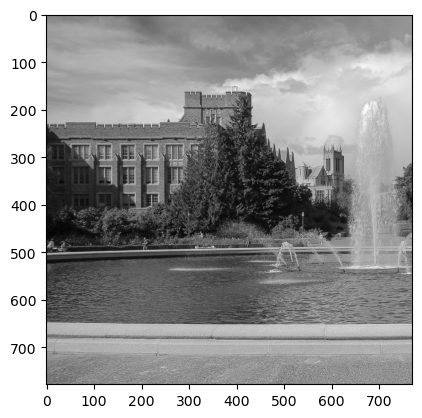

In [38]:
plt.imshow(fountain_1, cmap="gray")

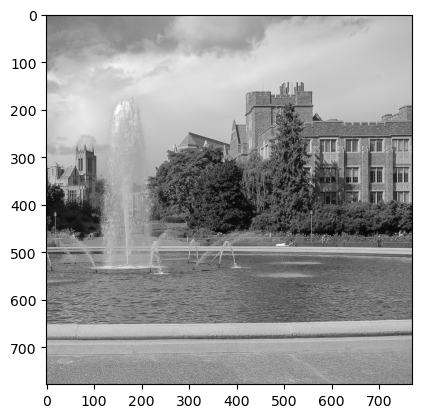

In [39]:
plt.imshow(fountain_2, cmap="gray")

In [40]:
def find_max(image, size, threshold) : # size - maximum filter mask size
    data_max = filters.maximum_filter(image, size)
    maxima = (image == data_max)
    diff = image > threshold
    maxima[diff == 0] = 0
    return np.nonzero(maxima)

In [41]:
def get_h_from_auto_corelation_matrix(image, sobel_size, gauss_size, K=0.05):
    # Gradient with Sobel
    Ix = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=sobel_size)
    Iy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=sobel_size)

    I2x = Ix**2
    I2y = Iy**2
    Ixy = Ix * Iy

    # Applying Gaussian blur
    gauss_tuple = (gauss_size, gauss_size)
    blurred_I2x = cv2.GaussianBlur(I2x, ksize=gauss_tuple, sigmaX=1)
    blurred_I2y = cv2.GaussianBlur(I2y, ksize=gauss_tuple, sigmaX=1)
    blurred_Ixy = cv2.GaussianBlur(Ixy, ksize=gauss_tuple, sigmaX=1)

    det = blurred_I2x * blurred_I2y - (blurred_Ixy) ** 2
    trace = blurred_I2x + blurred_I2y

    H = det - K * trace ** 2
    H_norm = cv2.normalize(H, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    return H_norm

In [42]:
def draw_corners(image, y_coords, x_coords):
    output_image = image.copy()
    
    for y, x in zip(y_coords, x_coords):
        cv2.putText(
            output_image, 
            "*", 
            (x, y), 
            cv2.FONT_HERSHEY_SIMPLEX, 
            0.5,
            (255, 0, 0),
            1
        )
    return output_image

### Fountain

In [43]:
fountain_1_H = get_h_from_auto_corelation_matrix(fountain_1, 7, 7)
fountain_2_H = get_h_from_auto_corelation_matrix(fountain_2, 7, 7)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


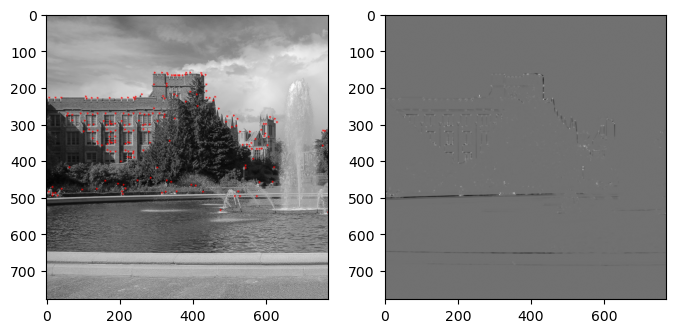

In [44]:
y_coords, x_coords = find_max(fountain_1_H, 7, 0.5)

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(draw_corners(cv2.cvtColor(fountain_1, cv2.COLOR_GRAY2BGR), y_coords, x_coords))
axis[1].imshow(fountain_1_H, cmap="gray")

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


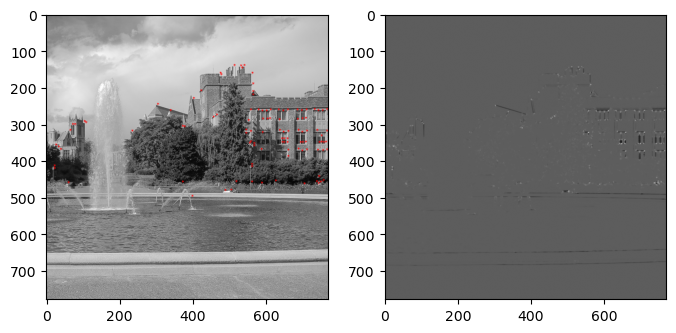

In [45]:
y_coords, x_coords = find_max(fountain_2_H, 7, 0.5)

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(draw_corners(cv2.cvtColor(fountain_2, cv2.COLOR_GRAY2BGR), y_coords, x_coords))
axis[1].imshow(fountain_2_H, cmap="gray")

### Building

In [46]:
building_1 = images[0]
building_2 = images[1]

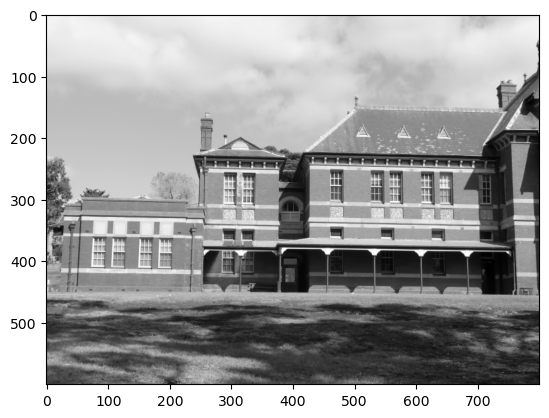

In [47]:
plt.imshow(building_1, cmap="gray")

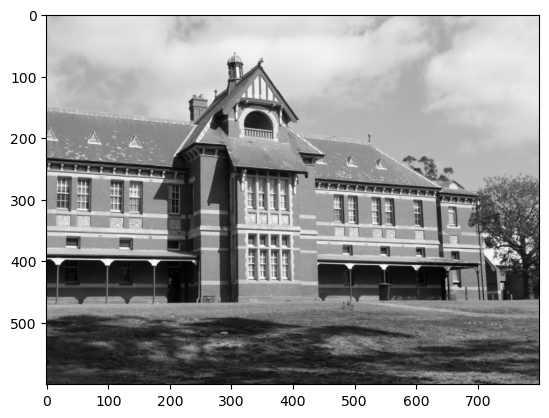

In [48]:
plt.imshow(building_2, cmap="gray")

In [49]:
building_1_H = get_h_from_auto_corelation_matrix(building_1, 7, 7)
building_2_H = get_h_from_auto_corelation_matrix(building_2, 7, 7)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


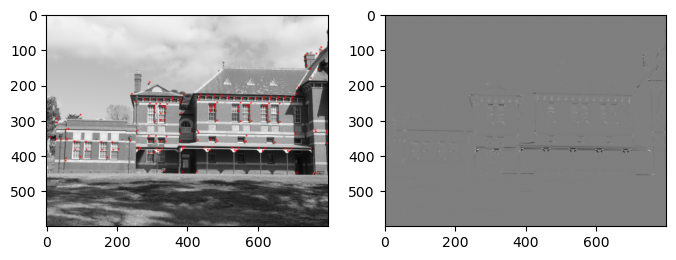

In [50]:
y_coords, x_coords = find_max(building_1_H, 7, 0.55)

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(draw_corners(cv2.cvtColor(building_1, cv2.COLOR_GRAY2BGR), y_coords, x_coords))
axis[1].imshow(building_1_H, cmap="gray")

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


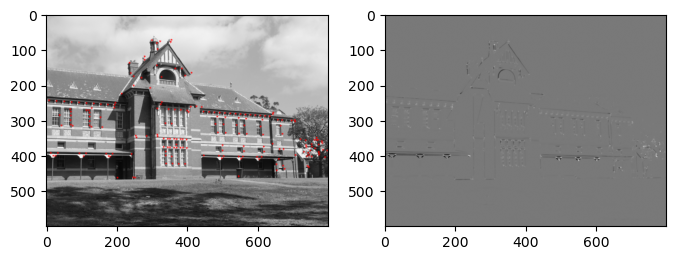

In [51]:
y_coords, x_coords = find_max(building_2_H, 7, 0.55)

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(draw_corners(cv2.cvtColor(building_2, cv2.COLOR_GRAY2BGR), y_coords, x_coords))
axis[1].imshow(building_2_H, cmap="gray")

## Feature Points

### Functions

In [52]:
def describe_feature_points(image, x_coords, y_coords, size):
    Y, X = image.shape
    pts = list(filter(lambda pt : pt[0] >= size and pt[0] < Y - size and pt[1] >= size and pt[1] < X - size, zip(y_coords, x_coords)))
    
    descriptors = []
    offset = size // 2
    
    for y, x in pts:
        patch = image[y - offset : y + offset + 1, x - offset : x + offset + 1]
        
        descriptors.append({
            "coords": (y, x),
            "patch": patch
        })
        
    return descriptors


In [53]:
def match_feature_points(desc_list_1, desc_list_2, N):
    feature_point_matches = []

    for desc_1 in desc_list_1:
        most_similar_description = None
        best_score = float("inf")

        for desc_2 in desc_list_2:
            score = (np.abs(desc_1["patch"] - desc_2["patch"])).sum()
            if score < best_score:
                most_similar_description = desc_2
                best_score = score

        feature_point_matches.append((desc_1["coords"], most_similar_description["coords"], best_score))

    return sorted(feature_point_matches, key=lambda x: x[2])[:N]


### Fountains

In [54]:
y_coords, x_coords = find_max(fountain_1_H, 7, 0.5)
fountain1_desc_list = describe_feature_points(fountain_1, x_coords, y_coords, 15)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


In [55]:
y_coords, x_coords = find_max(fountain_2_H, 7, 0.5)
fountain2_desc_list = describe_feature_points(fountain_2, x_coords, y_coords, 15)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


In [56]:
fountain_matches = match_feature_points(fountain1_desc_list, fountain2_desc_list, 20)

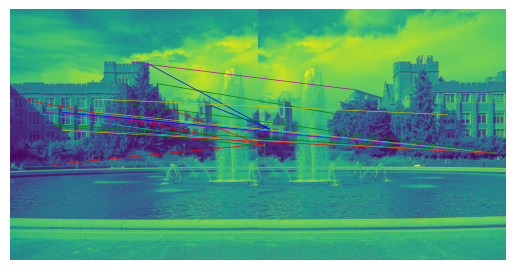

In [60]:
pm.plot_matches(fountain_1, fountain_2, fountain_matches)

### Buildings

In [61]:
y_coords, x_coords = find_max(building_1_H, 7, 0.55)
building_1_desc_list = describe_feature_points(building_1, x_coords, y_coords, 15)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


In [62]:
y_coords, x_coords = find_max(building_2_H, 7, 0.55)
building_2_desc_list = describe_feature_points(building_2, x_coords, y_coords, 15)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


In [63]:
building_matches = match_feature_points(building_1_desc_list, building_2_desc_list, 20)

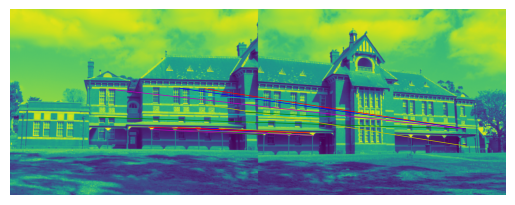

In [64]:
pm.plot_matches(building_1, building_2, building_matches)

### Eiffel Tower

In [65]:
eiffel_1 = images[2]
eiffel_2 = images[3]

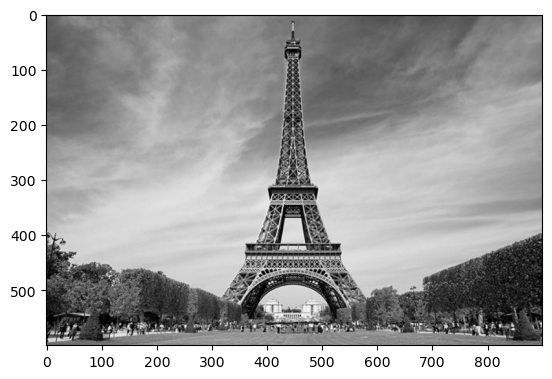

In [66]:
plt.imshow(eiffel_1, cmap="gray")

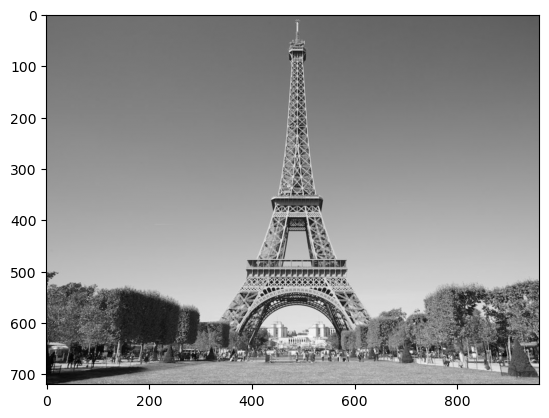

In [68]:
plt.imshow(eiffel_2, cmap="gray")

In [69]:
eiffel_1_H = get_h_from_auto_corelation_matrix(eiffel_1, 7, 7)
eiffel_2_H = get_h_from_auto_corelation_matrix(eiffel_2, 7, 7)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


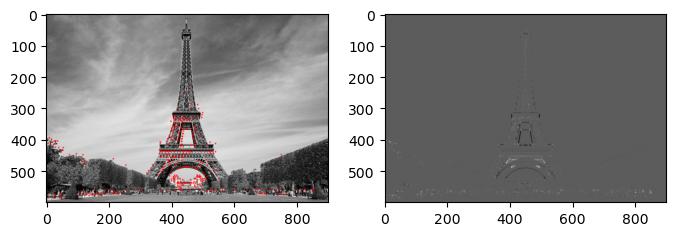

In [91]:
y_coords, x_coords = find_max(eiffel_1, 7, 230)

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(draw_corners(cv2.cvtColor(eiffel_1, cv2.COLOR_GRAY2BGR), y_coords, x_coords))
axis[1].imshow(eiffel_1_H, cmap="gray")

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


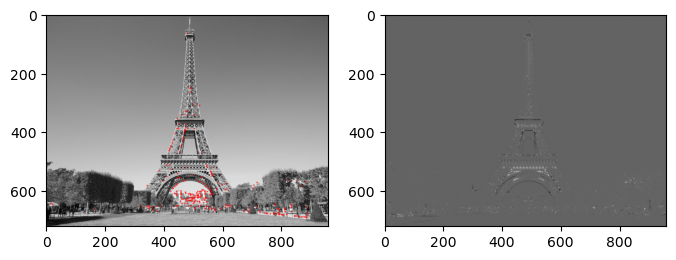

In [87]:
y_coords, x_coords = find_max(eiffel_2, 7, 230)

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(draw_corners(cv2.cvtColor(eiffel_2, cv2.COLOR_GRAY2BGR), y_coords, x_coords))
axis[1].imshow(eiffel_2_H, cmap="gray")

In [92]:
y_coords, x_coords = find_max(eiffel_1, 7, 230)
eiffel_1_desc_list = describe_feature_points(eiffel_1, x_coords, y_coords, 15)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


In [93]:
y_coords, x_coords = find_max(eiffel_2, 7, 230)
eiffel_2_desc_list = describe_feature_points(eiffel_2, x_coords, y_coords, 15)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25940\1870468016.py:2: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  data_max = filters.maximum_filter(image, size)


In [94]:
eiffel_matches = match_feature_points(eiffel_1_desc_list, eiffel_2_desc_list, 20)

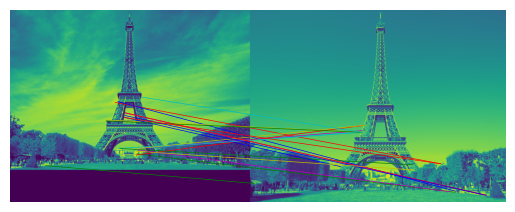

In [96]:
pm.plot_matches(eiffel_1, eiffel_2, eiffel_matches)